# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [519]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
# sns.set_style("whitegrid")
# sns.set_context("poster")

In [520]:
# matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
})

In [521]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file = 'Churn_Modelling.csv'

In [522]:
## TODO : make into a dataframe called df
df = pd.read_csv(file)

In [523]:
## TODO : output the first 5 lines
print(df.head())
print(f'Dataset has {df.shape[0]} row, {df.shape[1]} columns')
print(df.info())
print('Missing values: ')
print(df.isnull().sum())
print(f'Data types: {df.dtypes}')
print(f' Data basic statistics: \n ')
print(df.describe())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [524]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively

df_0 = df[df['Exited'] == 0.0]
df_1 = df[df['Exited'] == 1.0]

## Hypothesis 1: Age

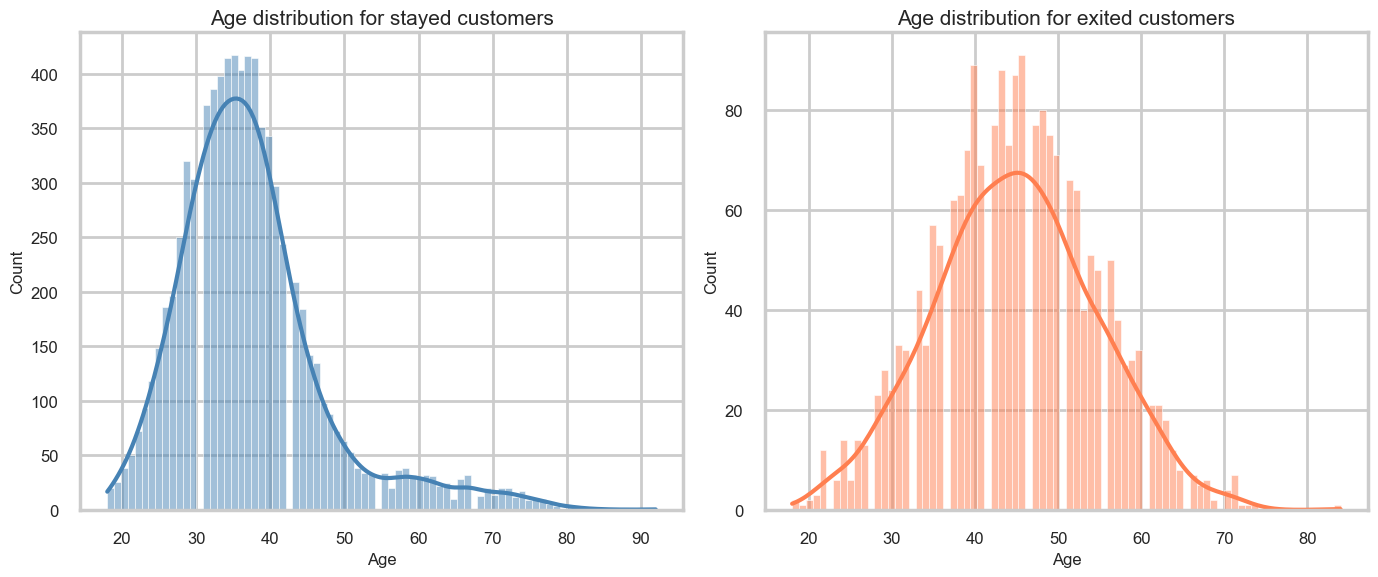

In [525]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=df_0, x='Age',kde=True, bins=80, color='steelblue', ax=axes[0])
axes[0].set_title('Age distribution for stayed customers')

sns.histplot(data=df_1, x='Age', kde=True,bins=80,color='coral', ax=axes[1])
axes[1].set_title('Age distribution for exited customers')

plt.tight_layout()
plt.show()



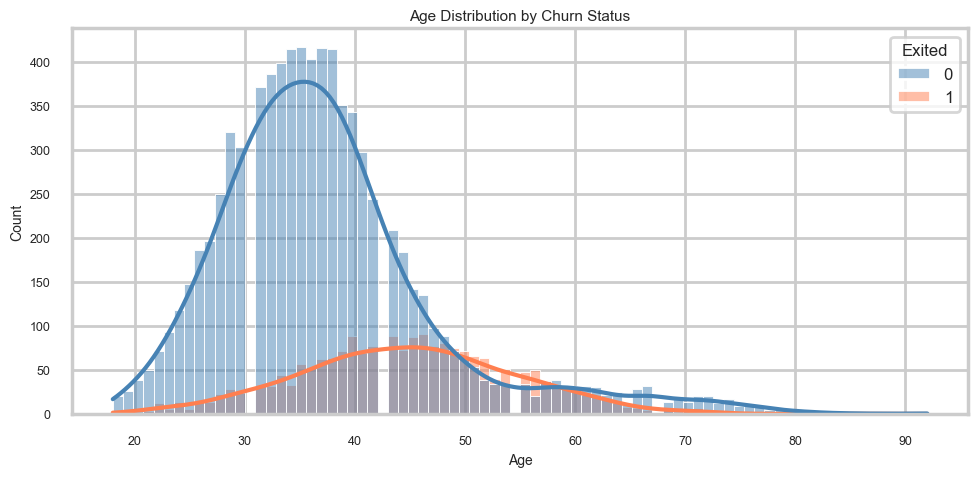

In [526]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Exited', kde=True, bins=80, palette=['steelblue', 'coral'])
plt.title('Age Distribution by Churn Status', fontsize=11)
plt.xlabel('Age', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [527]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.

age_mean_stayed = df_0['Age'].mean()
age_std_stayed = df_0['Age'].std()
age_mean_exited = df_1['Age'].mean()
age_std_exited = df_1['Age'].std()
print(f'Stayed customers:')
print(f"mean: {age_mean_stayed:.2f}, std: {age_std_stayed:.2f}")
print(f'Exited customers:')
print(f"mean: {age_mean_exited:.2f}, std: {age_std_exited:.2f}")


Stayed customers:
mean: 37.41, std: 10.13
Exited customers:
mean: 44.84, std: 9.76


In [528]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
import scipy.stats as stats
t_stat, p_value = stats.ttest_ind(df_0['Age'], df_1['Age'])
print(f"T-statistics: {t_stat}, P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print('There is a significant difference on Age between customers who stayed and exited.')
else:
    print('There is no significant difference on Age between customers who stayed and exited ')


T-statistics: -29.76681499437077, P-value: 0.0000
There is a significant difference on Age between customers who stayed and exited.


### Using Bootstrapping

In [529]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

In [530]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
observed_diff_age = df_0['Age'].mean() - df_1['Age'].mean()
print(f'The actual mean age difference: {observed_diff_age}')
overall_mean = df['Age'].mean()
print(f'The actual overall mean age is {overall_mean}')


# shift mean
df_0_age_shift = df_0['Age'] + overall_mean - df_0['Age'].mean()
df_1_age_shift = df_1['Age'] + overall_mean - df_1['Age'].mean()



The actual mean age difference: -7.429608256300263
The actual overall mean age is 38.9218


BS resampling for df_0 mean:
 38.93, 39.01, 39.08, 38.89, 38.53, 38.89, 39.04, 38.68, 38.95, 38.95
BS resampling for df_1 mean:
 38.51, 39.07, 38.94, 39.08, 38.89, 39.25, 39.23, 38.83, 38.82, 38.78
age differences of both mean group:
 0.42, -0.06, 0.15, -0.19, -0.36, -0.35, -0.19, -0.15, 0.13, 0.17
Std of stayed customers age means: 0.1094
Std of exited customers age means: 0.2219
Std of difference: 0.2518


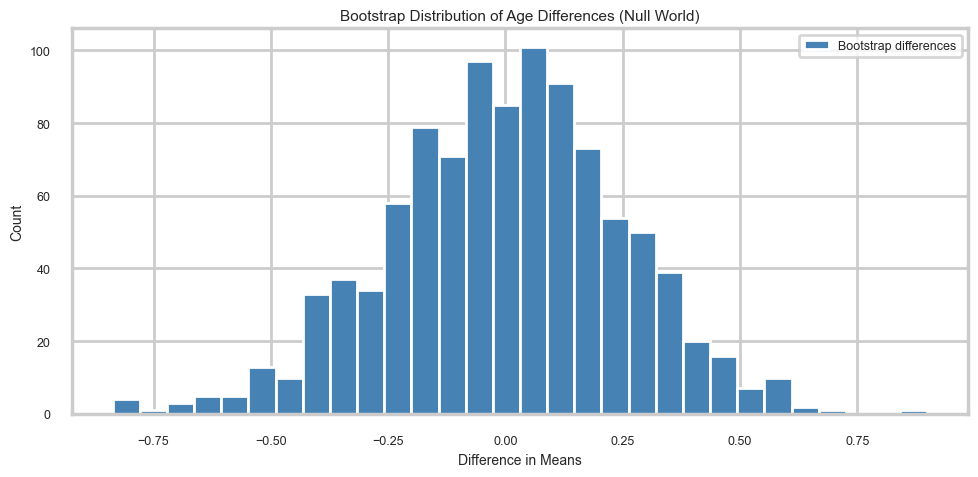

In [531]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.

bs_s_0 = bs_choice(df_0_age_shift, np.mean, 1000)
bs_s_1 = bs_choice(df_1_age_shift, np.mean, 1000)

values_bs0 = ', '.join(f"{x:.2f}" for x in bs_s_0[:10])
values_bs1 = ', '.join(f"{x:.2f}" for x in bs_s_1[:10])

print(f'BS resampling for df_0 mean:\n {values_bs0}')
print(f'BS resampling for df_1 mean:\n {values_bs1}')


bs_s_0_std = np.std(bs_s_0)
bs_s_1_std = np.std(bs_s_1)

bs_diff = bs_s_0 - bs_s_1
values_bs_diff = ', '.join(f"{x:.2f}" for x in bs_diff[:10])

print(f'age differences of both mean group:\n {values_bs_diff}')
std_diff = np.std(bs_diff)

print(f"Std of stayed customers age means: {bs_s_0_std:.4f}")
print(f"Std of exited customers age means: {bs_s_1_std:.4f}")
print(f"Std of difference: {std_diff:.4f}")

plt.figure(figsize=(10, 5))
plt.hist(bs_diff, bins=30, color='steelblue', edgecolor='white', label='Bootstrap differences')
# plt.axvline(observed_diff_age, color='red', linestyle='--', linewidth=1.5, label=f'Observed diff: {observed_diff_age:.2f}')
# plt.axvline(-observed_diff_age, color='orange', linestyle='--', linewidth=1.5, label=f'Negative observed diff: {-observed_diff_age:.2f}')
plt.title('Bootstrap Distribution of Age Differences (Null World)', fontsize=11)
plt.xlabel('Difference in Means', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()



In [532]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
# p_value = np.mean(np.abs(bs_diff) >= np.abs(observed_diff_age))
p_value = np.sum(np.abs(bs_diff) >= np.abs(observed_diff_age)) / len(bs_diff)

print(p_value)
alpha = 0.05
if p_value < alpha:
    print('There IS a significant difference in Age between customers who stayed and exited.')
else:
    print('There is NO significant difference in Age between customers who stayed and exited ')



0.0
There IS a significant difference in Age between customers who stayed and exited.


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Hypothesis 2: Credit Score

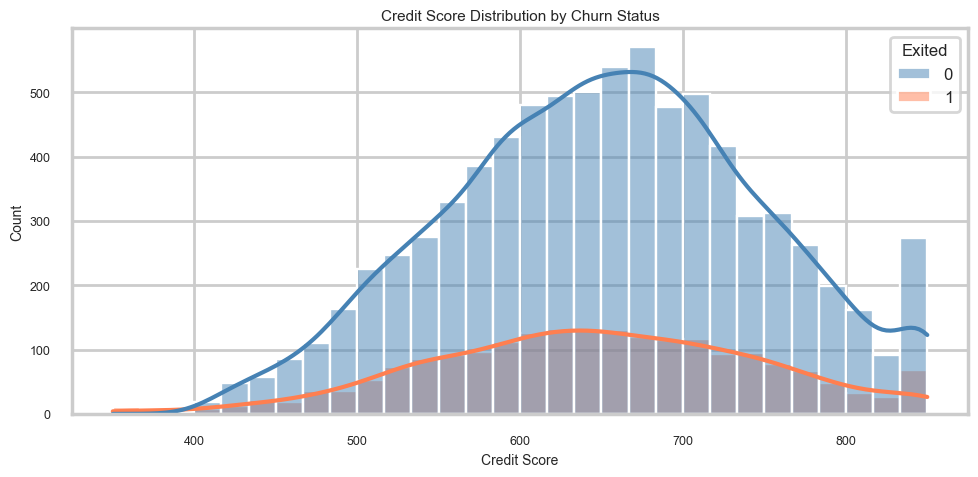

In [533]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='CreditScore', hue='Exited', bins=30, kde=True, palette=['steelblue', 'coral'])
plt.title('Credit Score Distribution by Churn Status', fontsize=11)
plt.xlabel('Credit Score', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [534]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).

df_0_CS = df[df['Exited']==0.0]['CreditScore']
df_1_CS = df[df['Exited']==1.0]['CreditScore']
df_0_CS_mean = df_0_CS.mean()
df_1_CS_mean = df_1_CS.mean()

print(f'mean of credit score for customers stayed: {df_0_CS_mean:.2f}')
print(f'mean of credit score for customers exited: {df_1_CS_mean:.2f}')


t_stat_cs, p_value_cs = stats.ttest_ind(df_0_CS, df_1_CS)
print(f'T-test p-value: {p_value_cs}')
alpha = 0.05
if p_value_cs < alpha:
    print('Reject H0: There is a significant difference in Credit Score between customers who stayed and exited.')
else:
    print('Failed to reject H0: There is no significant difference in Credit Score between customers who stayed and exited ')



mean of credit score for customers stayed: 651.85
mean of credit score for customers exited: 645.35
T-test p-value: 0.0067382138921923745
Reject H0: There is a significant difference in Credit Score between customers who stayed and exited.


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Hypothesis 3: Balance

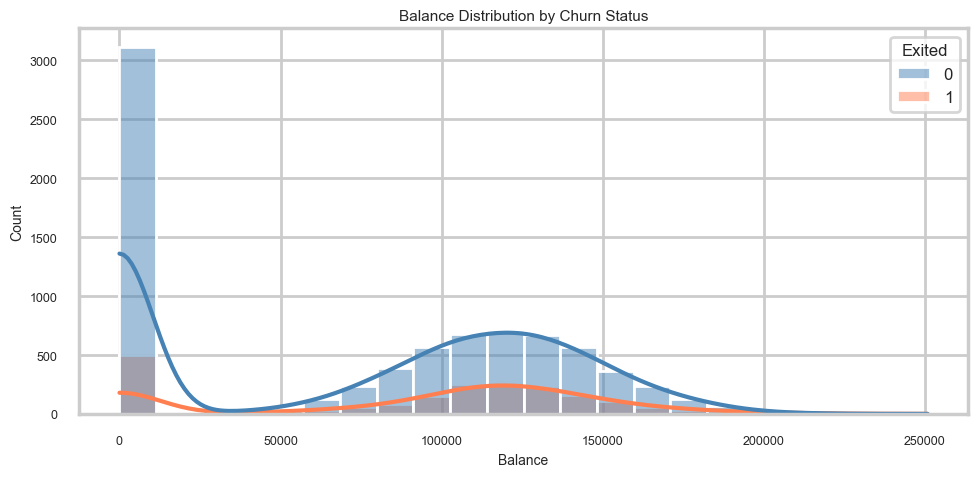

In [535]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Balance', hue='Exited',  kde=True, palette=['steelblue', 'coral'])
plt.title('Balance Distribution by Churn Status', fontsize=11)
plt.xlabel('Balance', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()


In [536]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
df_0_blc = df[df['Exited']==0.0]['Balance']
df_1_blc = df[df['Exited']==1.0]['Balance']
df_0_blc_mean = df_0_blc.mean()
df_1_blc_mean = df_1_blc.mean()

print(f'mean of balance for customers stayed: {df_0_blc_mean:.2f}')
print(f'mean of balance score for customers exited: {df_1_blc_mean:.2f}')


t_stat_blc, p_value_blc = stats.ttest_ind(df_0_blc, df_1_blc)
print(f'T-test p-value: {p_value_blc:.4f}')
alpha = 0.05
if p_value_blc < alpha:
    print('Reject H0: There is a significant difference in Balance between customers who stayed and exited.')
else:
    print('Failed to reject H0: There is no significant difference in Balance between customers who stayed and exited ')

mean of balance for customers stayed: 72745.30
mean of balance score for customers exited: 91108.54
T-test p-value: 0.0000
Reject H0: There is a significant difference in Balance between customers who stayed and exited.


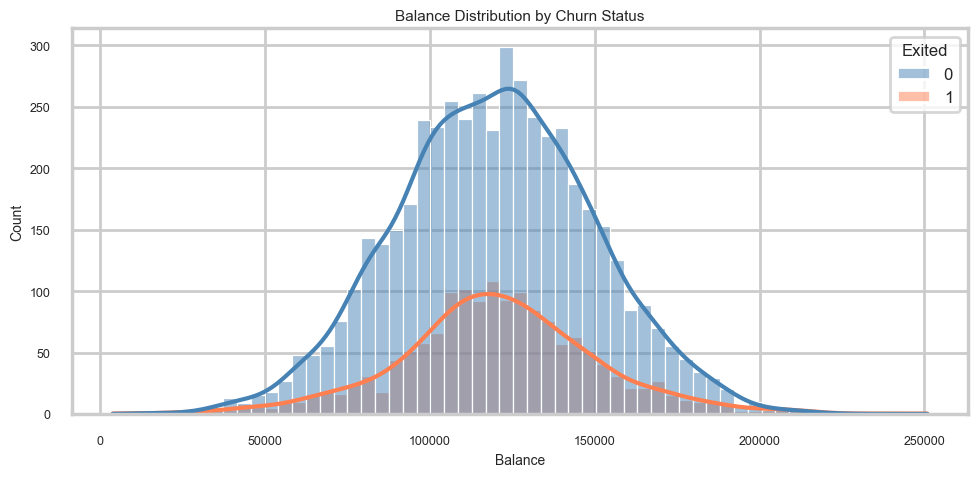

In [537]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
df_nonzero = df[df['Balance'] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(data=df_nonzero, x='Balance', hue='Exited',  kde=True, palette=['steelblue', 'coral'])
plt.title('Balance Distribution by Churn Status', fontsize=11)
plt.xlabel('Balance', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [538]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

df_0_blc = df_nonzero[df_nonzero['Exited']==0.0]['Balance']
df_1_blc = df_nonzero[df_nonzero['Exited']==1.0]['Balance']
df_0_blc_mean = df_0_blc.mean()
df_1_blc_mean = df_1_blc.mean()

print(f'mean of balance for customers stayed: {df_0_blc_mean:.2f}')
print(f'mean of balance score for customers exited: {df_1_blc_mean:.2f}')


t_stat_blc, p_value_blc = stats.ttest_ind(df_0_blc, df_1_blc)
print(f'T-test p-value: {p_value_blc:.4f}')
alpha = 0.05
if p_value_blc < alpha:
    print('Reject H0: There is a significant difference in Balance between customers who stayed and exited.')
else:
    print('Failed to reject H0: There is no significant difference in Balance between customers who stayed and exited ')

mean of balance for customers stayed: 119535.86
mean of balance score for customers exited: 120746.97
T-test p-value: 0.1692
Failed to reject H0: There is no significant difference in Balance between customers who stayed and exited 


## Conclusion

Do we reject the Null Hypothesis ? Why ?

## Hypothesis 4: Estimated Salary

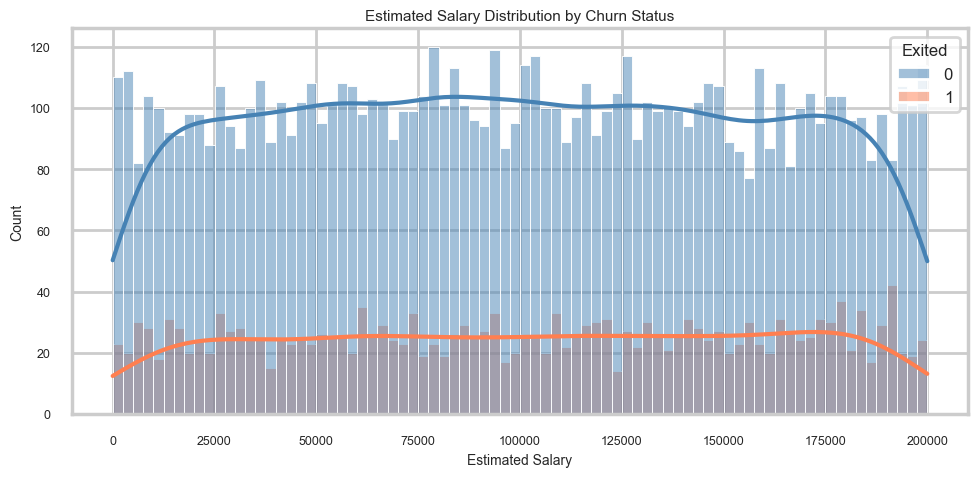

In [539]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='EstimatedSalary', hue='Exited', bins=80, kde=True, palette=['steelblue', 'coral'])
plt.title('Estimated Salary Distribution by Churn Status', fontsize=11)
plt.xlabel('Estimated Salary', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [540]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
df_0_es = df[df['Exited']==0.0]['EstimatedSalary']
df_1_es = df[df['Exited']==1.0]['EstimatedSalary']
df_0_es_mean = df_0_es.mean()
df_1_es_mean = df_1_es.mean()

print(f'mean of Estimated Salary for customers stayed: {df_0_es_mean:.2f}')
print(f'mean of Estimated Salary score for customers exited: {df_1_es_mean:.2f}')


t_stat_es, p_value_es = stats.ttest_ind(df_0_es, df_1_es)
print(f'T-test p-value: {p_value_es:.4f}')
alpha = 0.05
if p_value_es < alpha:
    print('Reject H0: There is a significant difference in Estimated Salary between customers who stayed and exited.')
else:
    print('Failed to reject H0: There is no significant difference in Estimated Salary between customers who stayed and exited ')

mean of Estimated Salary for customers stayed: 99738.39
mean of Estimated Salary score for customers exited: 101465.68
T-test p-value: 0.2264
Failed to reject H0: There is no significant difference in Estimated Salary between customers who stayed and exited 


### Using Bootstrapping

In [541]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
observed_diff_salary = df_0_es_mean - df_1_es_mean
print(f"observed_diff_salary: {observed_diff_salary}")
overall_mean_salary = df['EstimatedSalary'].mean()
print(f"overall_mean_salary: {overall_mean_salary}")

df_0_es_shifted = df_0_es + overall_mean_salary - df_0_es_mean
df_1_es_shifted = df_1_es + overall_mean_salary - df_1_es_mean




observed_diff_salary: -1727.2857587371254
overall_mean_salary: 100090.239881


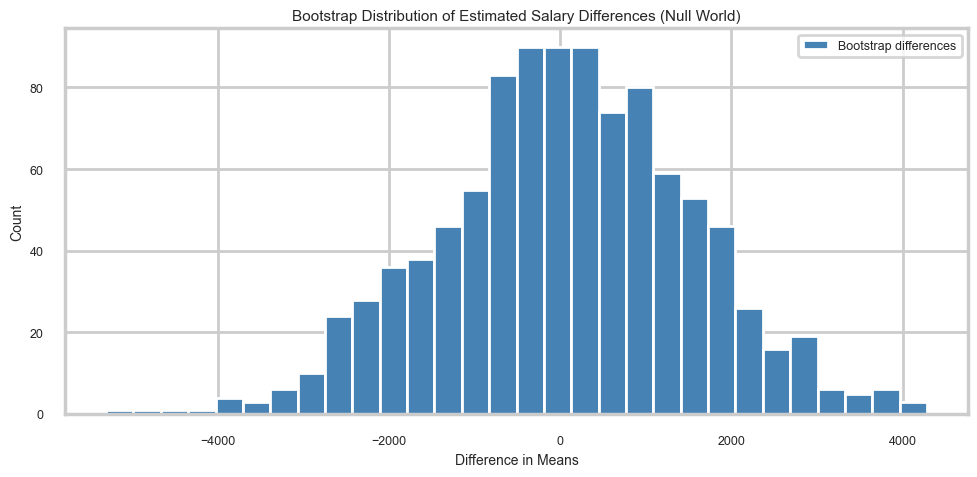

In [542]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.

bs_0_es = bs_choice(df_0_es_shifted, np.mean, 1000)
bs_1_es = bs_choice(df_1_es_shifted, np.mean, 1000)
bs_es_diff = bs_0_es - bs_1_es

plt.figure(figsize=(10, 5))
plt.hist(bs_es_diff, bins=30, color='steelblue', edgecolor='white', label='Bootstrap differences')
# plt.axvline(observed_diff_age, color='red', linestyle='--', linewidth=1.5, label=f'Observed diff: {observed_diff_age:.2f}')
# plt.axvline(-observed_diff_age, color='orange', linestyle='--', linewidth=1.5, label=f'Negative observed diff: {-observed_diff_age:.2f}')
plt.title('Bootstrap Distribution of Estimated Salary Differences (Null World)', fontsize=11)
plt.xlabel('Difference in Means', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [543]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.

bs_p_value_es = np.sum( np.abs(bs_es_diff) >= np.abs(observed_diff_salary) )/len(bs_es_diff)
print(f'Bootstrap Hypothesis test p-value: {bs_p_value_es}')

if bs_p_value_es <= 0.05:
    print('There is a significant difference in Estimated Salary between customers who stayed and exited.')
else:
    print('There is no significant difference in Estimated Salary between customers who stayed and exited ')


Bootstrap Hypothesis test p-value: 0.25
There is no significant difference in Estimated Salary between customers who stayed and exited 


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Final Conclusion
What will be the most helpful feature in predicting churning?


1. **Age** — showed a statistically significant difference between churned and 
   retained customers (p-value ≈ 0.000). Churned customers tend to be older.
   This is likely the strongest predictor of churn.

2. **Balance** — churned customers tend to have higher balances compared to 
   retained customers (visible from the distribution plot).
   But after removing the zero balanced customer, there's no significant difference on balance between two groups.

3. **Credit Score** — showed difference between the two groups. but the data was caped at 850 credit score , which could affect the mean for both groups, hence affecting the t-test.

4. **Estimated Salary** - showed no significant difference between two groups.

**Conclusion:** Age is the most helpful feature in predicting churn, supported 
by both the bootstrap hypothesis test (p < 0.05) and the visual distribution 
showing a clear separation between the two groups.

# What you will create
A predictive model that identifies customers who are likely to churn, helping the bank to focus retention efforts on high-risk customers.

A set of visualizations and insights from the model to guide business decisions.

For today’s daily challenge, we will predict whether customers will exit the bank in the near future (churn prediction).
Churn refers to customers who are likely to stop using the bank’s services in the near future. In this dataset, the bank could predict churn based on:

**Account balance**: Customers with low balances may be more likely to leave, especially if they feel they are not utilizing the bank’s services efficiently.

**Age and tenure**: Older customers with longer relationships might be more loyal, while younger or newer customers might be more likely to leave.

**Number of products**: Customers holding multiple products may have more reasons to stay loyal, so fewer products could correlate with higher churn risk.

**Credit score and transaction history**: A customer’s financial activity (like a history of low balances or minimal activity) could indicate disengagement, potentially predicting churn.

# 1. EDA (histogram, scatter, heatmap)
- Check shape, dtypes, .info(), .describe()
- Missing values — count and visualize
- Distribution plots (histograms, boxplots)
- Outlier detection (IQR, z-score, boxplot)
- Correlation heatmap
- Class imbalance check (df['Exited'].value_counts())
- Feature relationships (pairplot, groupby stats)

In [544]:
# as we see from before, there were no missing values and we've list all the important infos about the data, so i'll not repeat again here
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


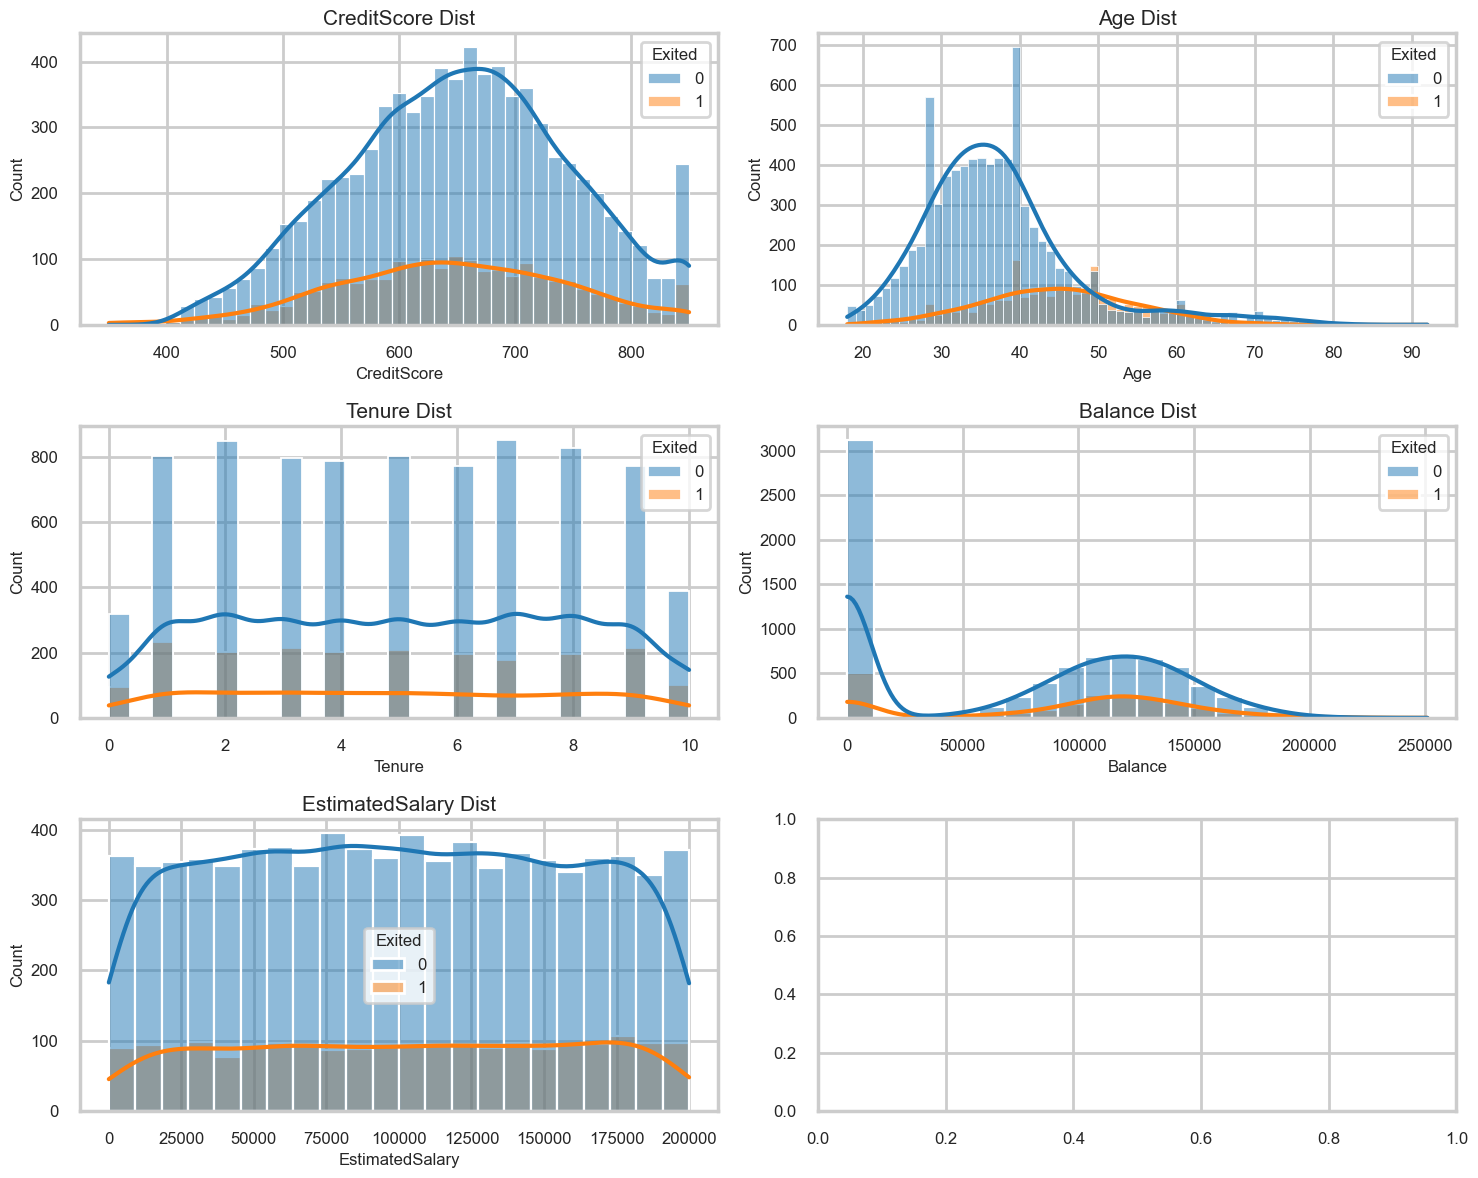

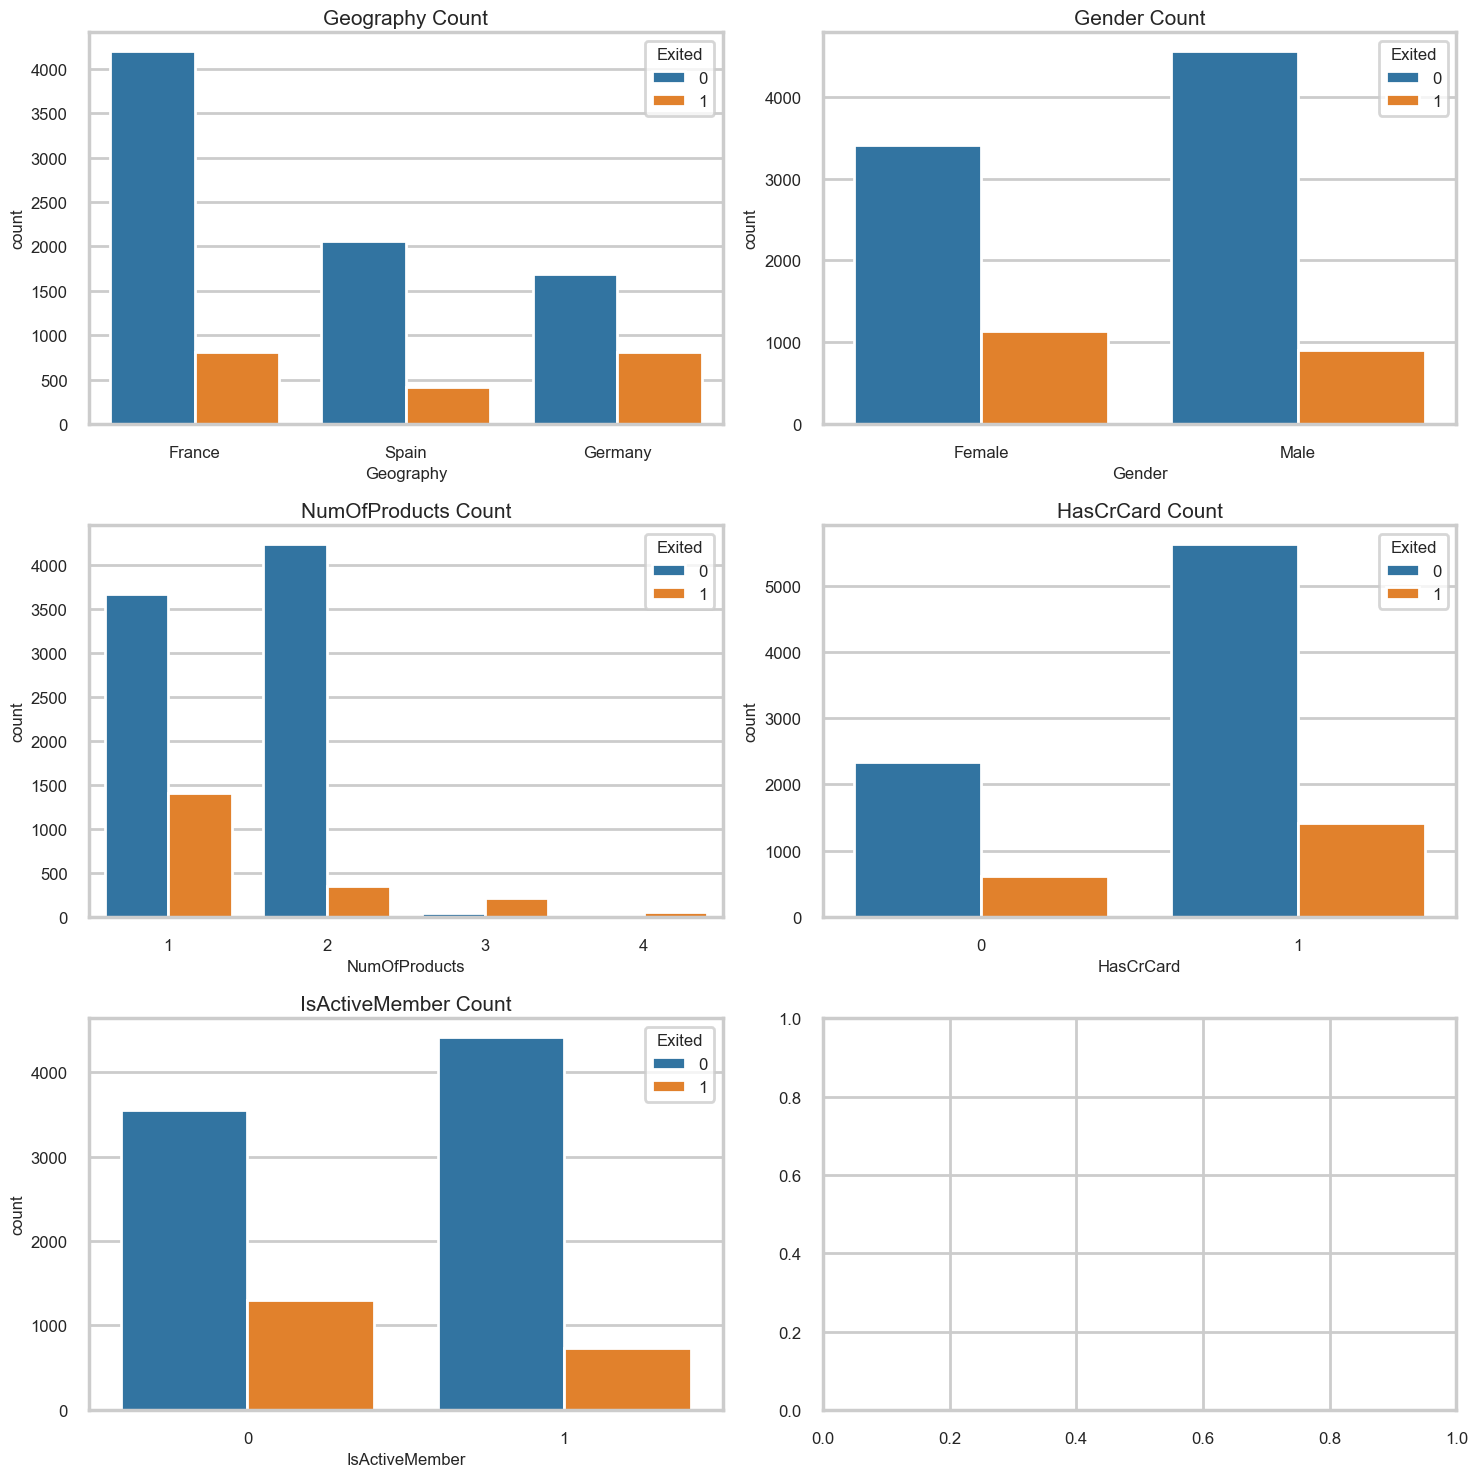

In [545]:
# distribution plots
histo_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
count_columns = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

# Histogram for continuous
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(histo_columns):
    sns.histplot(data=df, x=col, hue='Exited', kde=True, ax=axes[i])
    axes[i].set_title(f'{col} Dist')

plt.tight_layout()
plt.show()

# Countplot for categorical
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
for i, col in enumerate(count_columns):
    sns.countplot(data=df, x=col, hue='Exited', ax=axes[i])
    axes[i].set_title(f'{col} Count')
    
plt.tight_layout()
plt.show()

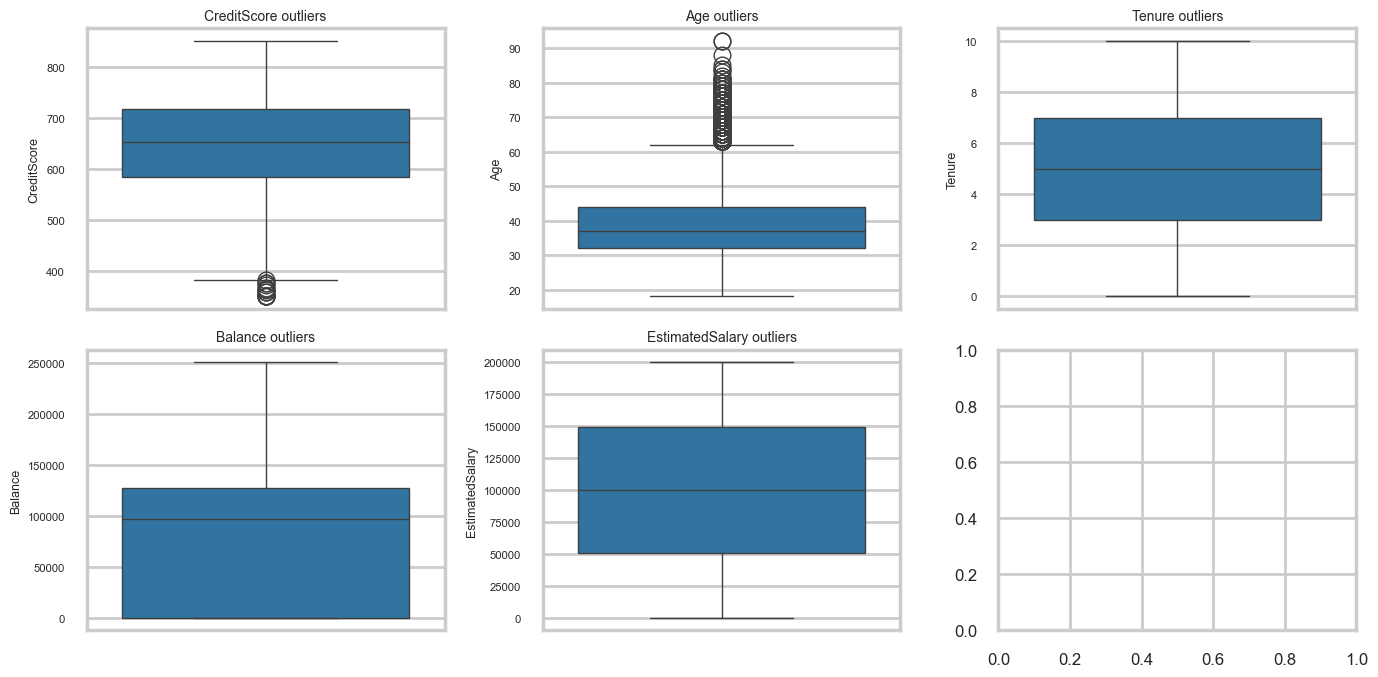

In [546]:
# Boxplot for detecting outliers
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

axes = axes.flatten()
for i, col in enumerate(histo_columns):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'{col} outliers', fontsize=10)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

In [547]:
cs_q1 = df['CreditScore'].quantile(0.25)
cs_q3 = df['CreditScore'].quantile(0.75)
cs_IQR = cs_q3 - cs_q1
print(df[(df['CreditScore'] < cs_q1 - 1.5 * cs_IQR)]['CreditScore'].count())
print(df[(df['CreditScore'] > cs_q3 + 1.5 * cs_IQR)]['CreditScore'].count())
outliers_cs = df[(df['CreditScore'] < cs_q1 - 1.5*cs_IQR) | (df['CreditScore'] > cs_q3 + 1.5*cs_IQR)]
print(outliers_cs['CreditScore'].describe())
print(f"Min: {outliers_cs['CreditScore'].min()}, Max: {outliers_cs['CreditScore'].max()}")

# df = df[(df['CreditScore'] >= cs_q1 - 1.5 * cs_IQR)]
print("15 outliers , but all valid credit scores, min-max 350-382 are just poor credit scores, not data errors")

age_q1 = df['Age'].quantile(0.25)
age_q3 = df['Age'].quantile(0.75)
age_IQR = age_q3 - age_q1
outliers_age = df[(df['Age'] < age_q1 - 1.5*age_IQR) | (df['Age'] > age_q3 + 1.5*age_IQR)]
print(outliers_age['Age'].describe())
print(f"Min: {outliers_age['Age'].min()}, Max: {outliers_age['Age'].max()}")
print(df[(df['Age'] < age_q1 - 1.5 * age_IQR)]['Age'].count())
print(df[(df['Age'] > age_q3 + 1.5 * age_IQR)]['Age'].count())

print('we got 359 age outliers and range between 63-92, those are real customers and likely important for churn prediction ')

# Cap instead of remove
df['Age'] = df['Age'].clip(lower=age_q1 - 1.5*age_IQR, upper=age_q3 + 1.5*age_IQR)



15
0
count     15.000000
mean     361.333333
std       11.362009
min      350.000000
25%      350.000000
50%      359.000000
75%      370.000000
max      382.000000
Name: CreditScore, dtype: float64
Min: 350, Max: 382
15 outliers , but all valid credit scores, min-max 350-382 are just poor credit scores, not data errors
count    359.000000
mean      69.270195
std        5.237059
min       63.000000
25%       65.000000
50%       68.000000
75%       72.000000
max       92.000000
Name: Age, dtype: float64
Min: 63, Max: 92
0
359
we got 359 age outliers and range between 63-92, those are real customers and likely important for churn prediction 


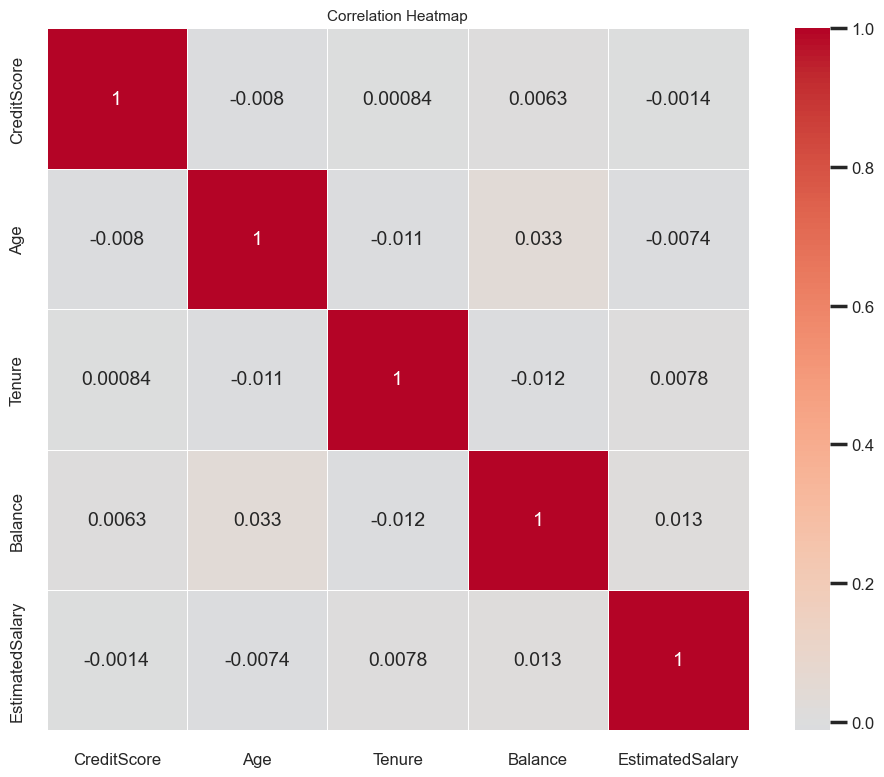

In [548]:
correlation_matrix = df[histo_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5)


plt.title('Correlation Heatmap', fontsize=11)
plt.tight_layout()
plt.show()

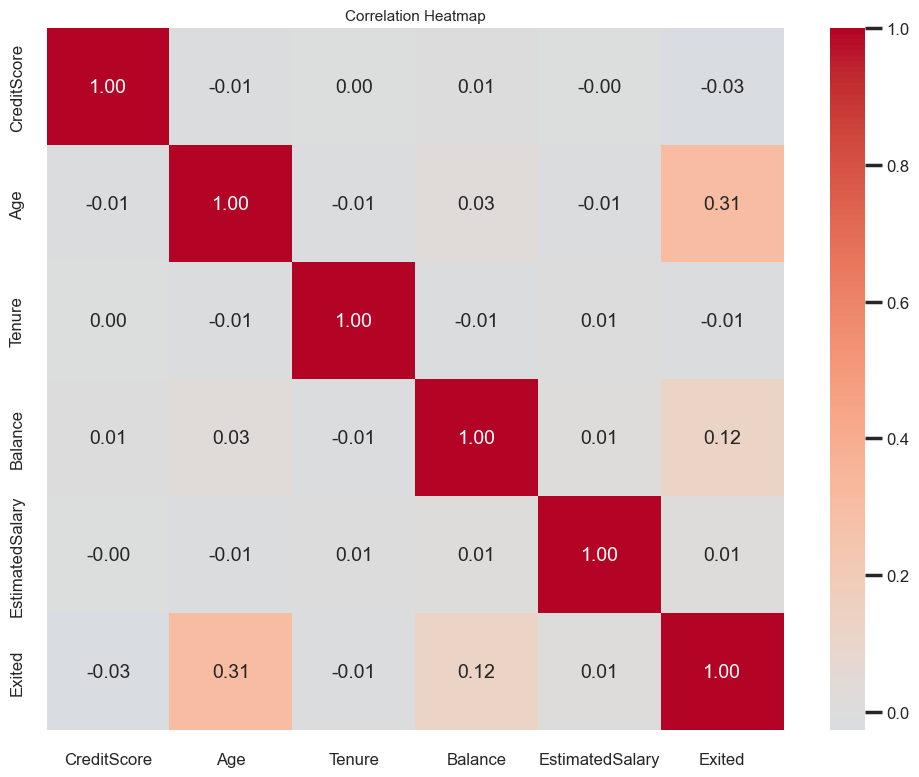

 from the correlation heatmap, we don;t see much correlations between the numerical columns and the exit status, only Age column has slight higher correlation


In [549]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[histo_columns + ['Exited']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=11)
plt.tight_layout()
plt.show()
print(" from the correlation heatmap, we don;t see much correlations between the numerical columns and the exit status, only Age column has slight higher correlation")

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.6
1    20.4
Name: proportion, dtype: float64


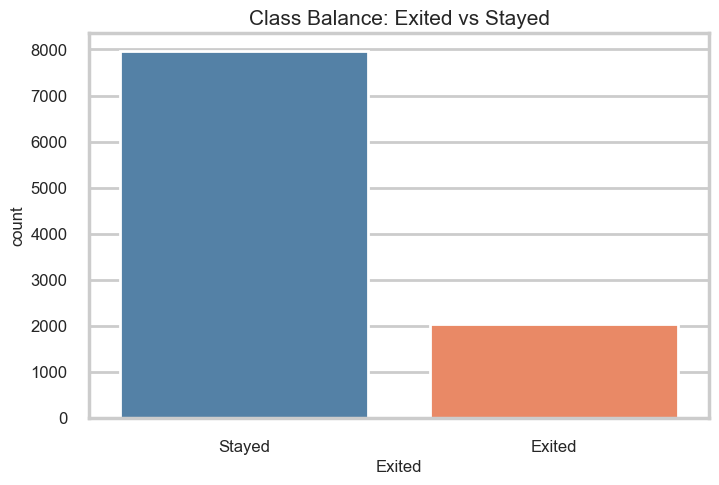

almost 80/20, imbalanced class dataset


In [550]:
# check class imbalance
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True).mul(100).round(1))

sns.countplot(data=df, x='Exited', hue='Exited', palette=['steelblue', 'coral'], legend=False)
plt.title('Class Balance: Exited vs Stayed')
plt.xticks([0, 1], ['Stayed', 'Exited'])
plt.show()

print('almost 80/20, imbalanced class dataset')

# 2. Data preprocessing and transforming

In [551]:
# drop useless columns
drop_columns = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=drop_columns)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [552]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB
None


In [553]:
# Define preprocesser
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
# binary_cols = ['Gender','HasCrCard', 'IsActiveMember']
numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
onehot_cols = ['Geography', 'NumOfProducts', 'Gender','HasCrCard', 'IsActiveMember']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_columns),
    # ('binary', LabelEncoder(), binary_cols),
    ('onehot', OneHotEncoder(), onehot_cols)
])

# 3. Model 
### Split data -> Build pipeline -> initialize model -> fit -> predict
- Classification : Logistic regression, Knn, SVM, random forest, XG Boosting
- Liner: Liner regression
- Grid Search Cross-Validation

In [554]:
# split data
from sklearn.model_selection import train_test_split
y = df['Exited']
X = df.drop(columns=['Exited'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, 
                                                      stratify=y)

print(y_train.value_counts(normalize=True))  # check ratio


Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64


In [ ]:
# List all the models we could use
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, recall_score

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(class_weight='balanced', random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42),
    'XG boosting': XGBClassifier(n_estimators=100, random_state=42)
}


results = {}

for name, model in models.items():
    # Build pipeline with preprocessor + model
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Fit and predict
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Store results
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),                    # for minority class (Exited=1)
        'ROC-AUC':   roc_auc_score(y_test, y_prob) if y_prob is not None else None,
    }
    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Exited']))





Model: Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.93      0.77      0.84      1593
      Exited       0.45      0.76      0.57       407

    accuracy                           0.76      2000
   macro avg       0.69      0.76      0.70      2000
weighted avg       0.83      0.76      0.78      2000


Model: KNN
              precision    recall  f1-score   support

      Stayed       0.85      0.95      0.90      1593
      Exited       0.65      0.34      0.45       407

    accuracy                           0.83      2000
   macro avg       0.75      0.65      0.67      2000
weighted avg       0.81      0.83      0.81      2000


Model: SVM
              precision    recall  f1-score   support

      Stayed       0.92      0.80      0.86      1593
      Exited       0.49      0.74      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.77      0.72      2000
weighted avg       0.8

# 4. Evaluate 
- Classification : accuracy, precision, recall, f1 score, POC(AUC)
- Liner regression: R^2, MSE, MAE, RMSE, residual plots 

In [557]:
# Summary table
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
print(results_df)

                     Accuracy    Recall  F1 Score   ROC-AUC
SVM                    0.7890  0.739558  0.587891  0.850644
Logistic Regression    0.7645  0.761671  0.568286  0.842167
Random Forest          0.8575  0.447174  0.560863  0.846638
XG boosting            0.8465  0.476658  0.558273  0.828460
KNN                    0.8280  0.341523  0.446945  0.759899


According to ROC_AUC value, SVM is the best model overall, which has the highest score on Roc-auc and F1 score, followed by Logistic regression and Random forest